# Constructing a Winning Formula with Sabermetrics
Created by Colton Laurence

## Data Prep

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

### Dataset

In [3]:
stats = pd.read_csv("https://raw.githubusercontent.com/ColtonLaurence/DTSC4050/refs/heads/main/PositionPlayerLeaderboards.csv?token=GHSAT0AAAAAADZFIQWFH7PQEHGQNKL2Z3BE2OK3RVA")
print("Dataset Shape: ", stats.shape)
stats.head(10)

Dataset Shape:  (1378, 44)


,Season,Name,Team,Age,G,PA,AB,BB%,K%,Swing%,...,CS,Pos,xBA,xSLG,xwOBA,AVG+,OPS+,ISO+,wRC+,WAR
0,2024,Aaron Judge,NYY,32,158,704,559,0.188920,0.242898,0.420104,...,0,-3.431070,0.304650,0.740077,0.480940,134.327089,226.054308,245.018551,219.783572,11.334959
1,2022,Aaron Judge,NYY,30,157,696,570,0.159483,0.251437,0.425327,...,3,-4.144947,0.303866,0.731575,0.468061,128.060993,212.415295,251.427396,206.154837,11.092547
2,2024,Bobby Witt Jr.,KCR,24,161,709,636,0.080395,0.149506,0.511735,...,12,7.061041,0.308842,0.582779,0.406941,138.397501,175.098272,165.579056,169.133932,10.489662
3,2018,Mookie Betts,BOS,25,136,614,520,0.131922,0.148208,0.356313,...,6,-5.272633,0.309364,0.607269,0.431400,138.575895,191.164132,176.388622,184.996974,10.186042
4,2025,Aaron Judge,NYY,33,152,679,541,0.182622,0.235641,0.436716,...,5,-10.279491,0.299911,0.708415,0.459256,135.780878,215.366417,220.363885,204.457870,10.126677
5,2018,Mike Trout,LAA,26,140,608,471,0.200658,0.203947,0.375541,...,2,0.225765,0.294045,0.602679,0.434751,124.943871,195.052985,189.647815,188.316304,9.416221
6,2023,Ronald Acuña Jr.,ATL,25,159,735,643,0.108844,0.114286,0.461898,...,14,-7.217077,0.351001,0.668489,0.461176,134.975779,171.788622,155.065135,171.448727,9.153117
7,2025,Cal Raleigh,SEA,28,159,705,596,0.137589,0.266667,0.517302,...,4,5.085734,0.231260,0.546678,0.370550,101.217108,159.831230,211.428868,161.114774,9.062879
8,2024,Shohei Ohtani,LAD,29,159,731,636,0.110807,0.221614,0.472164,...,4,-17.175924,0.309618,0.672090,0.443898,125.485394,183.701513,214.213879,179.678293,8.948559
9,2017,Aaron Judge,NYY,25,155,678,542,0.187316,0.306785,0.410840,...,4,-7.451988,0.287041,0.668492,0.450260,110.893996,175.919064,197.613815,173.816644,8.694270


## Exploratory Data Analysis

### Feature Selection

In [4]:
def get_user_metric_selection(df):
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ["Season", "Age", "xBA", "xSLG", "xwOBA", "AVG+", "OPS+", "ISO+", "wRC+", "WAR"]]

    print("\nAvailable Metrics:\n")
    for col in numeric_cols:
        print("-", col)

    print("\nEnter 'done' when finished.\n")

    selected_metrics = []

    while True:
        metric = input("Enter metric (or 'done'): ").strip()
        if metric.lower() == "done":
            break
        if metric not in numeric_cols:
            print("Metric not found or not available.")
            continue
        if metric in selected_metrics:
            print("Metric already selected.")
            continue
        selected_metrics.append(metric)

    return selected_metrics

def get_user_weights(selected_metrics):
    weights = {}
    for metric in selected_metrics:
        while True:
            try:
                weight = float(input(f"Weight for {metric}: "))
                if 0.01 <= weight <= 1.00:
                    weights[metric] = weight
                    break
                else:
                    print("Weight must be between 0.01 and 1.00.")
            except ValueError:
                print("Enter a numeric value.")
    return weights

def infer_metric_direction(df, metrics, anchor_metric="wRC+"):
    lower_is_better = []
    for metric in metrics:
        corr = df[metric].corr(df[anchor_metric])
        if corr < 0:
            lower_is_better.append(metric)
    return lower_is_better

def compute_player_value(df, metric_weights):
    df = df.copy()
    metrics = list(metric_weights.keys())
    lower_is_better = infer_metric_direction(df, metrics)

    for metric in lower_is_better:
        df[metric] = -df[metric]

    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[metrics])
    scaled_df = pd.DataFrame(scaled, columns=metrics, index=df.index)

    df["Player Value"] = sum(metric_weights[m] * scaled_df[m] for m in metrics)
    return df.sort_values("Player Value", ascending=False)

### Leaderboard

In [5]:
selected_metrics = get_user_metric_selection(stats)
metric_weights = get_user_weights(selected_metrics)
leaderboard = compute_player_value(stats, metric_weights)

print("\nTop 20 Players:\n")
print(leaderboard[["Name", "Season", "Player Value"]].head(20))


Available Metrics:

- G
- PA
- AB
- BB%
- K%
- Swing%
- O-Swing%
- Z-Swing%
- Contact%
- O-Contact%
- Z-Contact%
- Zone%
- SwStr%
- EV
- maxEV
- LA
- Barrel%
- HardHit%
- BABIP
- LD%
- GB%
- FB%
- IFFB%
- HR/FB
- Pull%
- Cent%
- Oppo%
- BsR
- Spd
- SB
- CS
- Pos

Enter 'done' when finished.

Enter metric (or 'done'): K%
Enter metric (or 'done'): HR/FB
Enter metric (or 'done'): BABIP
Enter metric (or 'done'): done
Weight for K%: 1
Weight for HR/FB: 1
Weight for BABIP: 1

Top 20 Players:

                 Name  Season  Player Value
697         Juan Soto    2020      6.414920
745       DJ LeMahieu    2020      5.979454
21   Christian Yelich    2018      5.359639
849       Nelson Cruz    2020      4.811629
50   Christian Yelich    2019      4.535843
6    Ronald Acuña Jr.    2023      4.213288
656     Marcell Ozuna    2020      4.212752
101     J.D. Martinez    2018      4.206113
0         Aaron Judge    2024      4.111566
4         Aaron Judge    2025      4.054805
593        José Abreu  

### Histograms

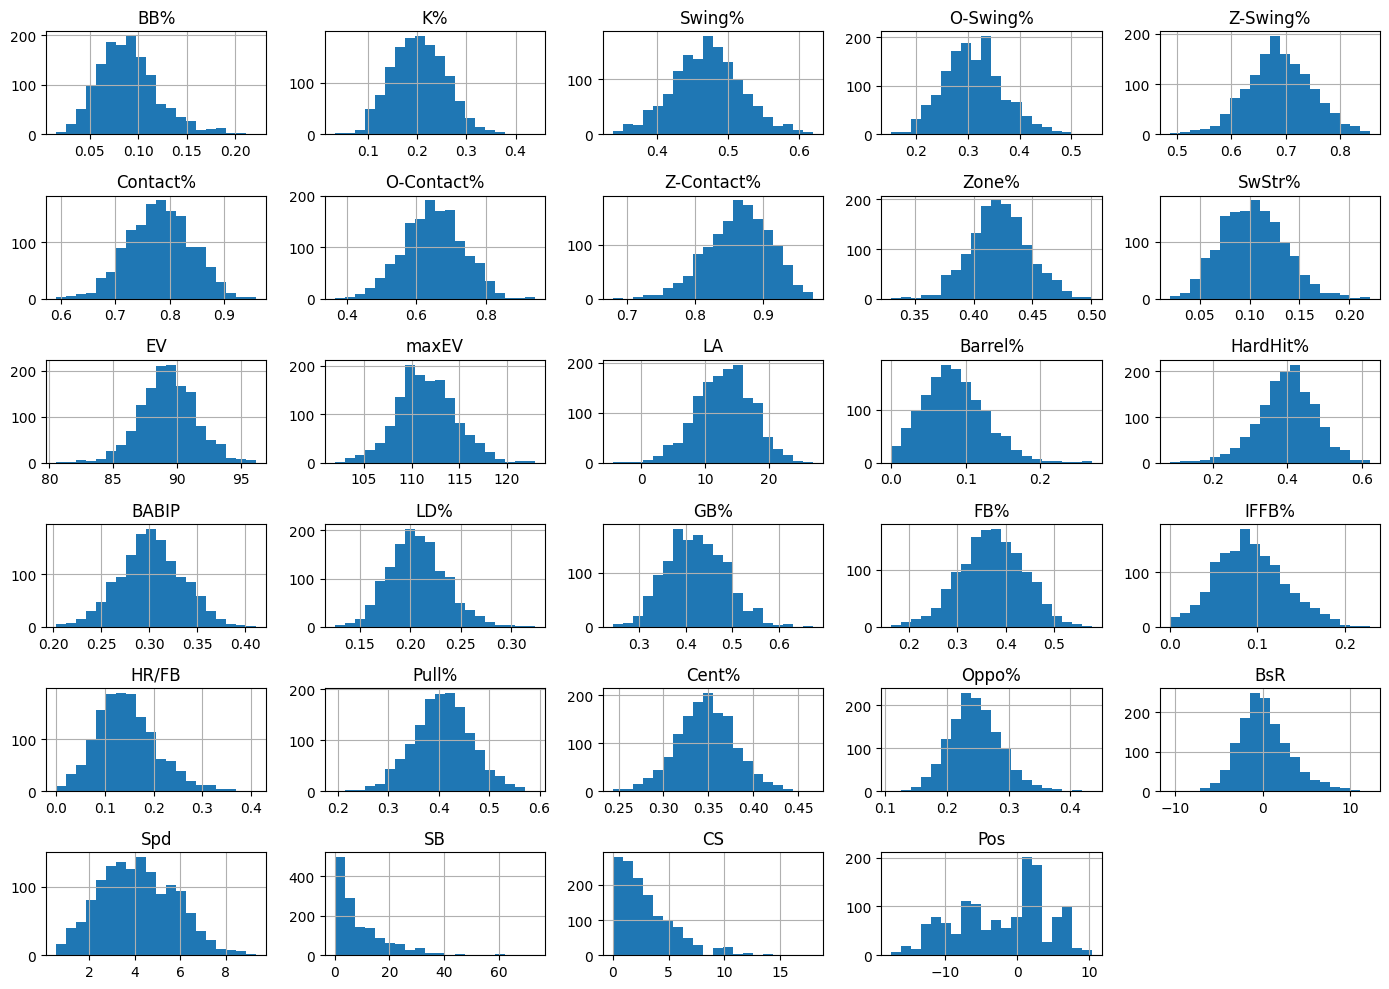

In [6]:
numeric_cols = [col for col in stats.select_dtypes(include="number").columns if col not in ["Season", "Age", "G", "PA", "AB", "xBA", "xSLG", "xwOBA", "AVG+", "OPS+", "ISO+", "wRC+", "WAR", "Player Value"]]

stats[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

### Percentile Distribution

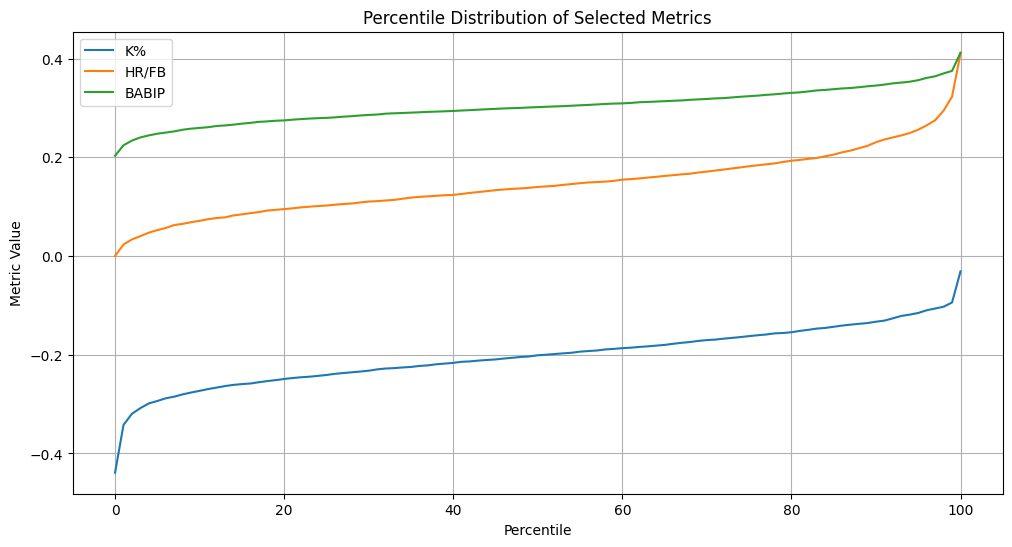

In [7]:
plt.figure(figsize=(12, 6))

for metric in selected_metrics:
    series = pd.to_numeric(leaderboard[metric], errors="coerce").dropna()
    if len(series) > 0:
        percentiles = np.percentile(series, np.arange(0, 101, 1))
        plt.plot(np.arange(0, 101, 1), percentiles, label=metric)

plt.title("Percentile Distribution of Selected Metrics")
plt.xlabel("Percentile")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)
plt.show()

## Correlation

### Additional Feature Selection

In [8]:
all_numeric_for_correlation = [col for col in leaderboard.select_dtypes(include="number").columns.tolist() if col not in ["Season", "Age", "xBA", "xSLG", "xwOBA", "AVG+", "OPS+", "ISO+", "wRC+", "WAR", "Player Value"]]
remaining_cols = [col for col in all_numeric_for_correlation if col not in selected_metrics]

if not remaining_cols:
    print("\nNo additional metrics available for correlation analysis.")
else:
    print("\nAvailable metrics to correlate with selected metrics:")
    for col in remaining_cols:
        print("-", col)

    print("\nEnter metrics to correlate one at a time (or type 'done' to skip'):")
    correlation_metrics = []
    while True:
        metric = input("Enter metric (or 'done'): ").strip()
        if metric.lower() == "done":
            break
        if metric not in remaining_cols:
            print("Metric not found. Choose from the list above.")
            continue
        if metric in correlation_metrics:
            print("Metric already selected.")
            continue
        correlation_metrics.append(metric)


Available metrics to correlate with selected metrics:
- G
- PA
- AB
- BB%
- Swing%
- O-Swing%
- Z-Swing%
- Contact%
- O-Contact%
- Z-Contact%
- Zone%
- SwStr%
- EV
- maxEV
- LA
- Barrel%
- HardHit%
- LD%
- GB%
- FB%
- IFFB%
- Pull%
- Cent%
- Oppo%
- BsR
- Spd
- SB
- CS
- Pos

Enter metrics to correlate one at a time (or type 'done' to skip'):
Enter metric (or 'done'): Z-Swing%
Enter metric (or 'done'): Pull%
Enter metric (or 'done'): LD%
Enter metric (or 'done'): done


### Correlation with Features


--- Correlation Heatmap for Selected Metrics ---



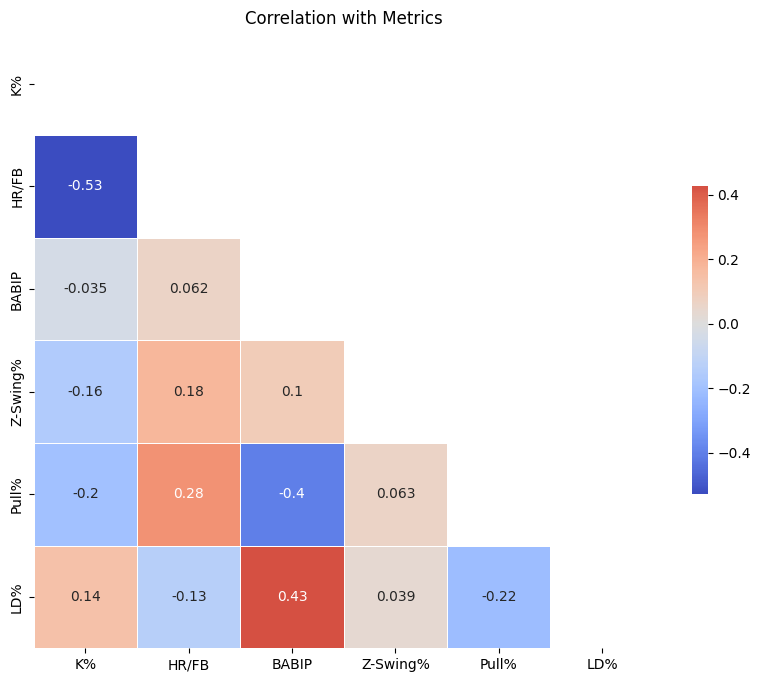

In [9]:
if correlation_metrics:
    corr_cols = selected_metrics + correlation_metrics
    corr_matrix = leaderboard[corr_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

    print("\n--- Correlation Heatmap for Selected Metrics ---\n")
    plt.figure(figsize = (10, 8))
    sns.heatmap(
        corr_matrix,
        mask = mask,
        annot = True,
        cmap = "coolwarm",
        center = 0,
        linewidths = 0.5,
        cbar_kws = {"shrink": 0.5}
    )
    plt.title("Correlation with Metrics")
    plt.show()

### Correlation with wRC+


--- Correlation of Selected Metrics with wRC+ ---



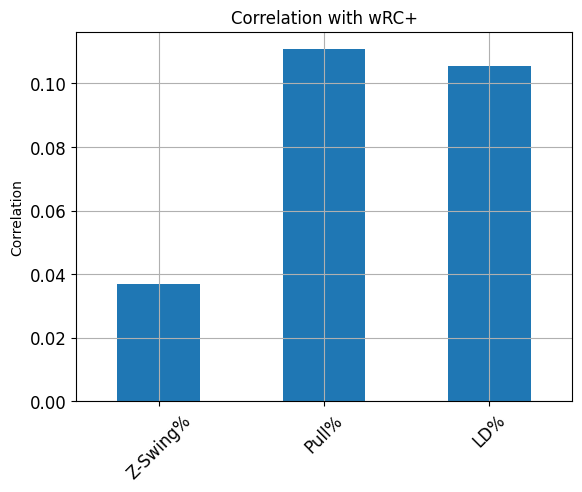

In [10]:
if correlation_metrics:
    print("\n--- Correlation of Selected Metrics with wRC+ ---\n")
    corr_with_value = leaderboard[correlation_metrics].corrwith(leaderboard["wRC+"])
    corr_with_value.plot.bar(title = "Correlation with wRC+", fontsize = 12, rot = 45, grid = True)
    plt.ylabel("Correlation")
    plt.show()

### Correlation with WAR


--- Correlation of Selected Metrics with WAR ---



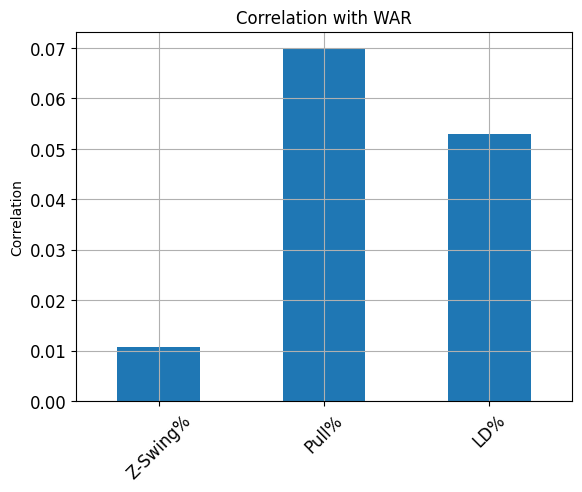

In [11]:
if correlation_metrics:
    print("\n--- Correlation of Selected Metrics with WAR ---\n")
    corr_with_value = leaderboard[correlation_metrics].corrwith(leaderboard["WAR"])
    corr_with_value.plot.bar(title = "Correlation with WAR", fontsize = 12, rot = 45, grid = True)
    plt.ylabel("Correlation")
    plt.show()

### Correlation with Player Value


--- Correlation of Selected Metrics with Player Value ---



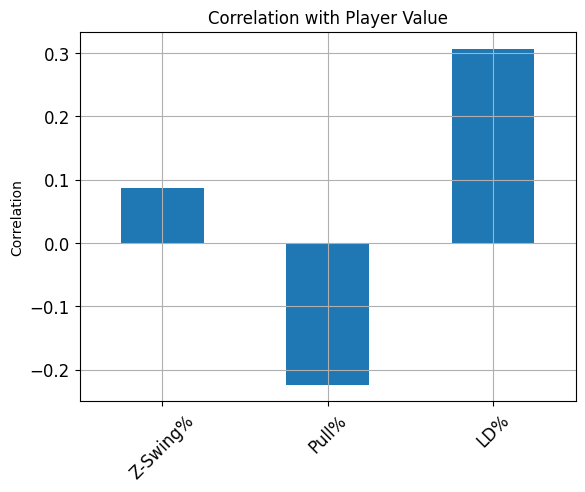

In [12]:
if correlation_metrics:
    print("\n--- Correlation of Selected Metrics with Player Value ---\n")
    corr_with_value = leaderboard[correlation_metrics].corrwith(leaderboard["Player Value"])
    corr_with_value.plot.bar(title = "Correlation with Player Value", fontsize = 12, rot = 45, grid = True)
    plt.ylabel("Correlation")
    plt.show()

## Predictive Modeling

### Forecasting Functions

In [13]:
def get_player_input():
    player_name = input("Player Name: ").strip()
    player_age = int(input("Age (from most recent season): ").strip())

    global stats
    if stats is None:
        print("Error: 'stats' DataFrame not loaded. Please run the data loading cell first.")
        return None, None, None

    numeric_cols = stats.select_dtypes(include="number").columns.tolist()
    exclude_cols = ["Season", "Age", "xBA", "xSLG", "xwOBA", "AVG+", "OPS+", "ISO+", "wRC+", "WAR"]
    available_metrics = [col for col in numeric_cols if col not in exclude_cols]

    print("\nAvailable Metrics:\n")
    for col in available_metrics:
        print(f"- {col}")

    # New placement for career metric selection instructions
    print("\nSelect metrics to track across career.")
    print("Enter metric, or type 'done' to finish metric selection.")

    selected_metrics_for_all_seasons = [] # Stores metrics chosen in the first season
    while True: # Loop for career metric selection
        metric_selection_input = input("Enter metric (or 'done'): ").strip()
        if metric_selection_input.lower() == "done":
            break
        if metric_selection_input not in available_metrics:
            print(f"Metric '{metric_selection_input}' not found or not available. Please choose from the available list.")
            continue
        if metric_selection_input in selected_metrics_for_all_seasons:
            print(f"Metric '{metric_selection_input}' already selected.")
            continue
        selected_metrics_for_all_seasons.append(metric_selection_input)

    if not selected_metrics_for_all_seasons:
        print("No metrics selected for the first season. Exiting player input.")
        return None, None, None

    seasons_data = []
    season_num_counter = 1

    # Now enter season data based on the selected metrics
    while True:
        print(f"\n--- Season {season_num_counter} (Most Recent to Oldest) ---")
        season_metrics = {}

        # Instructions for entering season values (consistent for all seasons)
        print("Enter single-season metrics from most recent to oldest.")
        print("Enter 'done' to finish season.\n") # Keeping this line as it was in the user's desired output example.

        print(f"Entering values for selected metrics: {', '.join(selected_metrics_for_all_seasons)}") # More explicit
        for metric in selected_metrics_for_all_seasons:
            value = input(f"Value for {metric}: ").strip()
            try:
                season_metrics[metric] = float(value)
            except ValueError:
                print(f"Invalid input for {metric}. Using NaN.")
                season_metrics[metric] = np.nan

        # Check if the current season_metrics dictionary is empty or contains only NaNs
        if not season_metrics or all(pd.isna(v) for v in season_metrics.values()):
            print("No metrics or valid values entered for this season. Stopping input.")
            break

        seasons_data.append(season_metrics)
        more = input("Enter another season? (y/n): ").strip().lower()
        if more != "y":
            break
        season_num_counter += 1

    # Reverse seasons_data so it's in oldest-to-most-recent order for apply_recency_weights
    return player_name, player_age, seasons_data[::-1]

In [14]:
def apply_recency_weights(seasons_data):
    n = len(seasons_data)
    weights = np.linspace(1/n, 1, n)
    weighted_avg = {}
    all_metrics = set().union(*seasons_data)
    for metric in all_metrics:
        vals = [s.get(metric, np.nan) for s in seasons_data]
        vals = np.array(vals, dtype=float)
        weighted_avg[metric] = np.nansum(vals * weights) / np.nansum(weights)
    return weighted_avg

In [15]:
def build_aging_curves(stats, skill_cols):

    """
    Computes average year-to-year change for each skill metric by age.
    Returns:
        aging_dict[metric][age] = average delta from age -> age+1
    """

    stats_sorted = stats.sort_values(["Name", "Season"]).copy()

    aging_dict = {}

    for metric in skill_cols:

        if metric not in stats.columns:
            continue

        # Compute year-to-year delta per player
        stats_sorted[f"{metric}_delta"] = (
            stats_sorted
            .groupby("Name")[metric]
            .diff()
        )

        # Compute average delta by age
        age_deltas = (
            stats_sorted
            .groupby("Age")[f"{metric}_delta"]
            .mean()
            .dropna()
        )

        aging_dict[metric] = age_deltas.to_dict()

    return aging_dict

In [16]:
def apply_aging_curves(df, aging_curves, volatile_metrics=None):

    """
    Applies empirical aging deltas to skill metrics only.
    Does NOT age volatile stats.
    """

    if volatile_metrics is None:
        volatile_metrics = []

    age = df["Age"].iloc[0]

    for metric in aging_curves:

        if metric in df.columns and metric not in volatile_metrics:

            if age in aging_curves[metric]:

                delta = aging_curves[metric][age]
                df.loc[df.index[0], metric] += delta

    return df

In [17]:
def compute_derived_metrics(user_metrics, user_age, stats, k=30, age_window=1):

    user_df = pd.DataFrame([user_metrics])

    age_filtered = stats[
        (stats["Age"] >= user_age - age_window) &
        (stats["Age"] <= user_age + age_window)
    ].copy()

    if age_filtered.empty:
        age_filtered = stats.copy()

    outcome_cols = [
        "xBA", "xSLG", "xwOBA",
        "AVG+", "OPS+", "ISO+",
        "wRC+", "WAR"
    ]

    exclude_cols = ["Season", "Age"] + outcome_cols

    numeric_cols = age_filtered.select_dtypes(include="number").columns.tolist()

    skill_cols = [
        col for col in user_df.columns
        if col in numeric_cols and col not in exclude_cols
    ]

    age_filtered = age_filtered.dropna(subset=skill_cols)

    if age_filtered.empty:
        return {}, {}, {}

    scaler = StandardScaler()
    scaled_hist = scaler.fit_transform(age_filtered[skill_cols])
    scaled_user = scaler.transform(user_df[skill_cols])

    nn = NearestNeighbors(n_neighbors=min(k, len(age_filtered)))
    nn.fit(scaled_hist)

    _, indices = nn.kneighbors(scaled_user)
    comparables = age_filtered.iloc[indices[0]]

    median_vals = comparables[outcome_cols].quantile(0.50).to_dict()
    p25_vals = comparables[outcome_cols].quantile(0.25).to_dict()
    p75_vals = comparables[outcome_cols].quantile(0.75).to_dict()

    return median_vals, p25_vals, p75_vals

In [18]:
def forecast_10_years(player_name, player_age, seasons_data, stats):

    # ----------------------------
    # Step 1: Create starting skills
    # ----------------------------

    weighted_skills = apply_recency_weights(seasons_data)
    current_skills = weighted_skills.copy()

    # Identify skill columns automatically
    outcome_cols = [
        "xBA", "xSLG", "xwOBA",
        "AVG+", "OPS+", "ISO+",
        "wRC+", "WAR"
    ]

    exclude_cols = ["Season", "Age"] + outcome_cols

    skill_cols = [
        col for col in stats.columns
        if col not in exclude_cols
        and stats[col].dtype != "object"
    ]

    # ----------------------------
    # Step 2: Build empirical aging curves
    # ----------------------------

    aging_curves = build_aging_curves(stats, skill_cols)

    volatile_metrics = ["BABIP", "HR/FB"]

    forecast = []
    age = player_age

    if not stats.empty and 'Season' in stats.columns:
        start_forecast_year = stats['Season'].max() + 1
    else:
        start_forecast_year = 2026

    # ----------------------------
    # Step 3: Forecast Loop
    # ----------------------------

    for year_idx in range(10):

        age += 1
        current_year = start_forecast_year + year_idx

        skill_df = pd.DataFrame([{
            "Season": current_year,
            "Age": age,
            **current_skills
        }])

        # Apply dataset-derived aging
        aged_skill_df = apply_aging_curves(
            skill_df.copy(),
            aging_curves,
            volatile_metrics
        )

        aged_skills = aged_skill_df.iloc[0].drop(["Season", "Age"]).to_dict()

        # Re-run comparable search at this age
        median_outcomes, p25_outcomes, p75_outcomes = compute_derived_metrics(
            aged_skills,
            age,
            stats
        )

        row = {
            "Season": current_year,
            "Age": age,
            **aged_skills,
            **{f"{k}_p50": v for k, v in median_outcomes.items()},
            **{f"{k}_p25": v for k, v in p25_outcomes.items()},
            **{f"{k}_p75": v for k, v in p75_outcomes.items()}
        }

        forecast.append(row)

        current_skills = aged_skills

    forecast_df = pd.DataFrame(forecast)
    forecast_df["Player Name"] = player_name

    return forecast_df

In [19]:
def plot_forecast(forecast_df):
    player_name = forecast_df['Player Name'].iloc[0]
    forecast_metrics = [col for col in forecast_df.columns if col not in ['Player Name', 'Season', 'Age']]
    num_metrics = len(forecast_metrics)
    fig_height = max(6, num_metrics * 2)
    plt.figure(figsize=(12, fig_height))
    for i, metric in enumerate(forecast_metrics):
        plt.subplot(num_metrics, 1, i + 1)
        sns.lineplot(x='Age', y=metric, data=forecast_df, marker='o')
        plt.title(f'{metric} Forecast for {player_name}')
        plt.xlabel('Age')
        plt.ylabel(metric)
        plt.grid(True)
    plt.tight_layout()
    plt.show()

In [20]:
def plot_comparative_forecast(forecast_df, stats):
    player_name = forecast_df['Player Name'].iloc[0]

    # List of original outcome metrics, which will appear as _p50 in forecast_df
    outcome_base_names = ["xBA", "xSLG", "xwOBA", "AVG+", "OPS+", "ISO+", "wRC+", "WAR"]

    comparable_forecast_metrics = []

    # Identify skill metrics (those that are not outcome_base_names with _pXX suffix)
    skill_metrics_in_forecast = [col for col in forecast_df.columns
                                 if col not in ['Player Name', 'Season', 'Age']
                                 and not any(col.startswith(obn) and '_p' in col for obn in outcome_base_names)]

    # Add skill metrics to the list for comparative plotting
    for skill_metric in skill_metrics_in_forecast:
        comparable_forecast_metrics.append(skill_metric)

    # Add _p50 versions of outcome metrics to the list for comparative plotting
    for outcome_base in outcome_base_names:
        p50_col = f"{outcome_base}_p50"
        if p50_col in forecast_df.columns:
            comparable_forecast_metrics.append(p50_col)

    # Now iterate through the selected comparable metrics for plotting
    for metric_to_plot in comparable_forecast_metrics:
        plt.figure(figsize=(10, 6))

        # Plot the player's forecast line
        sns.lineplot(x='Age', y=metric_to_plot, data=forecast_df, marker='o', label=f'{player_name} Forecast', color='red')

        # Determine the base metric name for historical data in the original 'stats' DataFrame
        base_metric_for_stats = metric_to_plot
        for outcome_base in outcome_base_names:
            if metric_to_plot.startswith(outcome_base) and '_p50' in metric_to_plot:
                base_metric_for_stats = outcome_base
                break

        # Plot historical data if available in the original 'stats' DataFrame
        if base_metric_for_stats in stats.columns:
            age_group_median = stats.groupby('Age')[base_metric_for_stats].median()
            plt.plot(age_group_median.index, age_group_median.values, linestyle='--', label='Historical Median', color='blue')

            q25 = stats.groupby('Age')[base_metric_for_stats].quantile(0.25)
            q75 = stats.groupby('Age')[base_metric_for_stats].quantile(0.75)
            plt.fill_between(q25.index, q25.values, q75.values, color='lightblue', alpha=0.4, label='Historical IQR')
        else:
            print(f"Warning: Historical data for '{base_metric_for_stats}' not found in 'stats' for comparative plotting.")

        plt.title(f'{metric_to_plot} Forecast vs. Historical Percentiles for {player_name}')
        plt.xlabel('Age')
        plt.ylabel(metric_to_plot)
        plt.legend()
        plt.grid(True)
        plt.show()
    # Note: plt.tight_layout() here would only affect the last displayed plot if plt.show() is called in a loop.
    # It's kept for consistency with previous user code structure.
    plt.tight_layout()

### Forecasting Data Input

In [21]:
player_name, player_age, seasons_data = get_player_input()
projection = forecast_10_years(player_name, player_age, seasons_data, stats)

Player Name: Colton Laurence
Age (from most recent season): 24

Available Metrics:

- G
- PA
- AB
- BB%
- K%
- Swing%
- O-Swing%
- Z-Swing%
- Contact%
- O-Contact%
- Z-Contact%
- Zone%
- SwStr%
- EV
- maxEV
- LA
- Barrel%
- HardHit%
- BABIP
- LD%
- GB%
- FB%
- IFFB%
- HR/FB
- Pull%
- Cent%
- Oppo%
- BsR
- Spd
- SB
- CS
- Pos

Select metrics to track across career.
Enter metric, or type 'done' to finish metric selection.
Enter metric (or 'done'): K%
Enter metric (or 'done'): Swing%
Enter metric (or 'done'): HR/FB
Enter metric (or 'done'): Cent%
Enter metric (or 'done'): Z-Contact%
Enter metric (or 'done'): done

--- Season 1 (Most Recent to Oldest) ---
Enter single-season metrics from most recent to oldest.
Enter 'done' to finish season.

Entering values for selected metrics: K%, Swing%, HR/FB, Cent%, Z-Contact%
Value for K%: .137
Value for Swing%: .46
Value for HR/FB: .189
Value for Cent%: .352
Value for Z-Contact%: .908
Enter another season? (y/n): y

--- Season 2 (Most Recent to Olde

### Player Forecasting


10-Year Forecast for Colton Laurence:

   Season  Age  Z-Contact%  HR/FB     Cent%    Swing%        K%   xBA_p50  \
0    2026   25    0.901195  0.186  0.342209  0.462911  0.131787  0.279309   
1    2027   26    0.904244  0.186  0.347064  0.469471  0.127278  0.280361   
2    2028   27    0.905033  0.186  0.346581  0.469174  0.121897  0.280361   
3    2029   28    0.902330  0.186  0.345979  0.466900  0.126566  0.273890   
4    2030   29    0.905128  0.186  0.345702  0.468316  0.126634  0.270236   
5    2031   30    0.903297  0.186  0.339432  0.472815  0.131349  0.268239   
6    2032   31    0.905631  0.186  0.344190  0.469136  0.128881  0.266973   
7    2033   32    0.905420  0.186  0.337798  0.469833  0.128289  0.270341   
8    2034   33    0.896219  0.186  0.343541  0.474802  0.140232  0.272775   
9    2035   34    0.897160  0.186  0.348163  0.474077  0.142473  0.277826   

   xSLG_p50  xwOBA_p50  ...    wRC+_p25   WAR_p25   xBA_p75  xSLG_p75  \
0  0.487675   0.361683  ...  109.903307

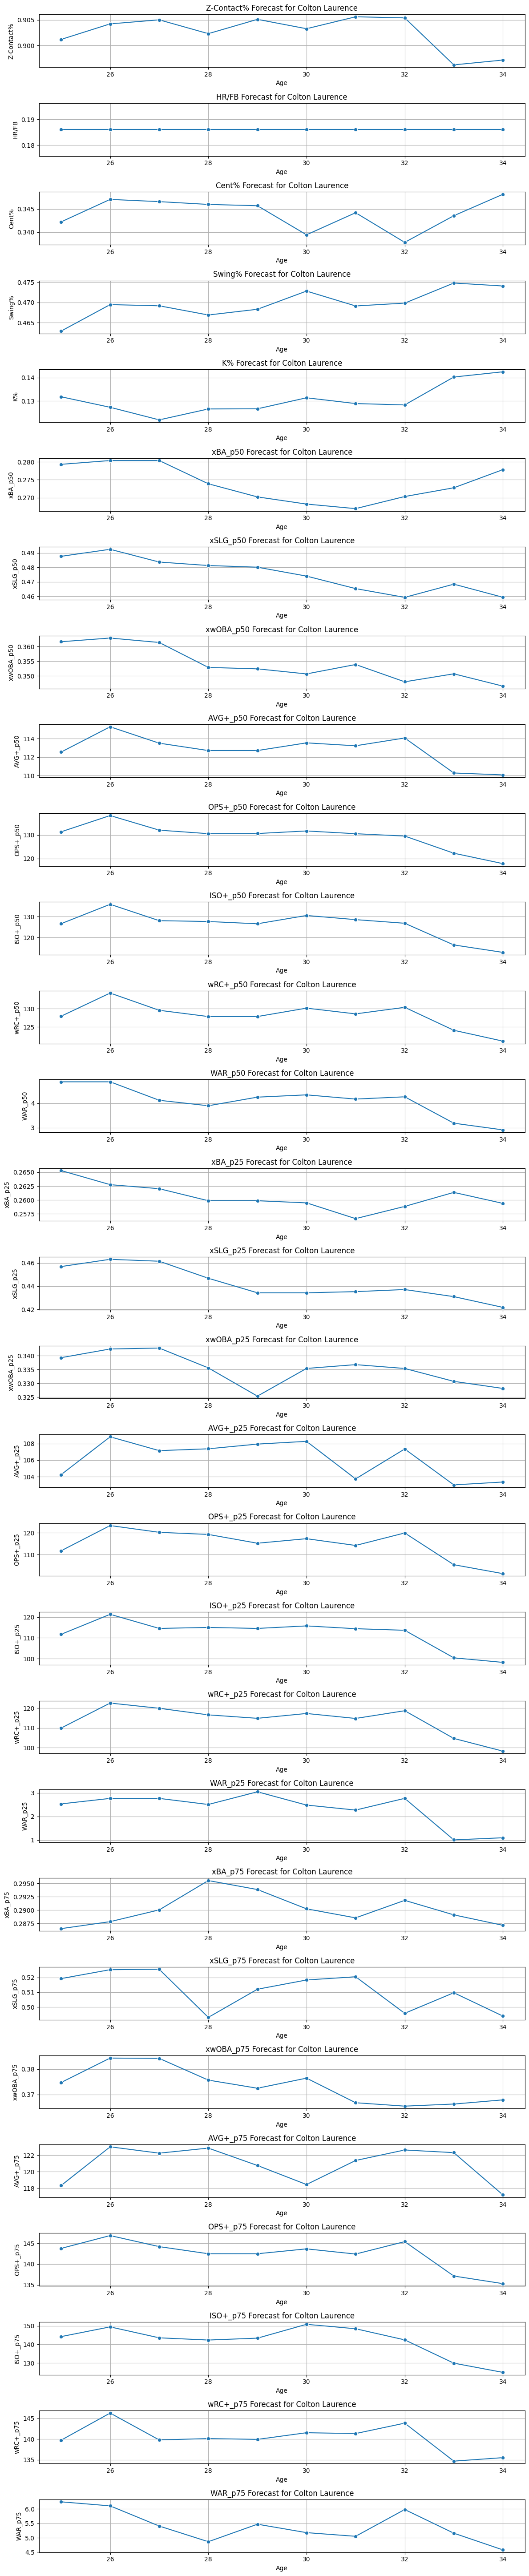

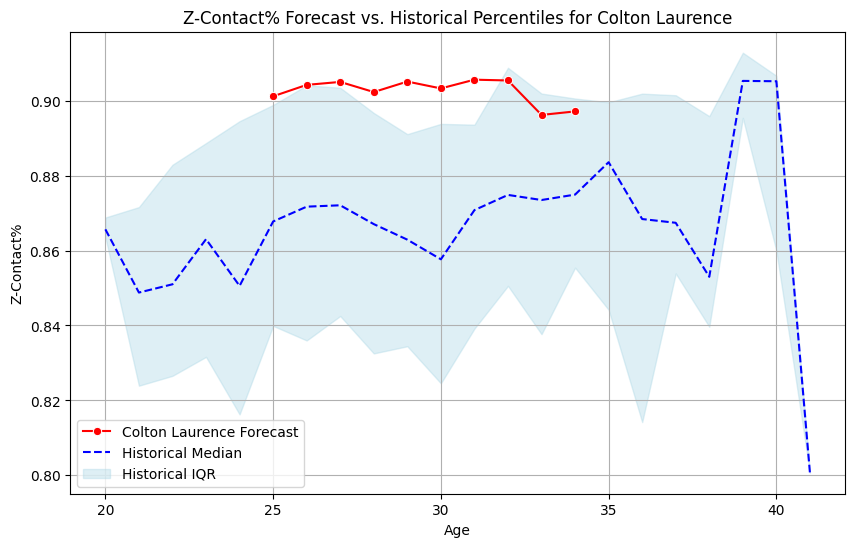

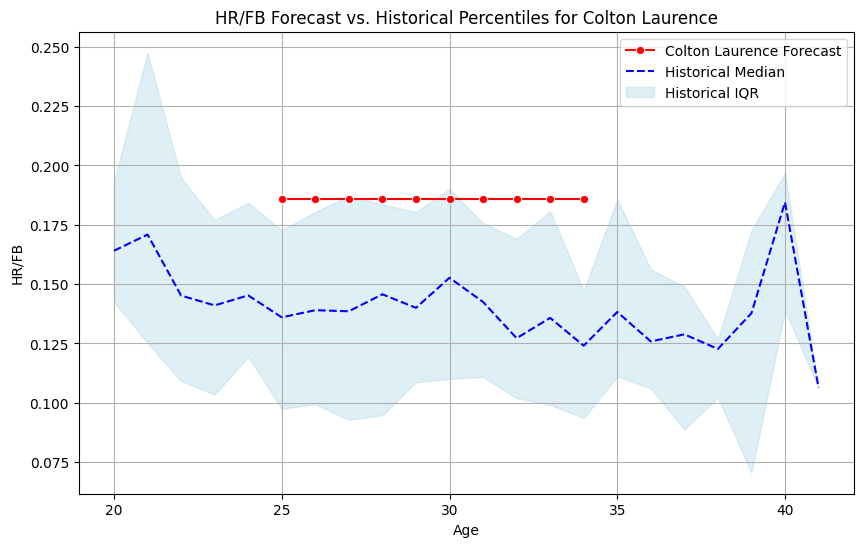

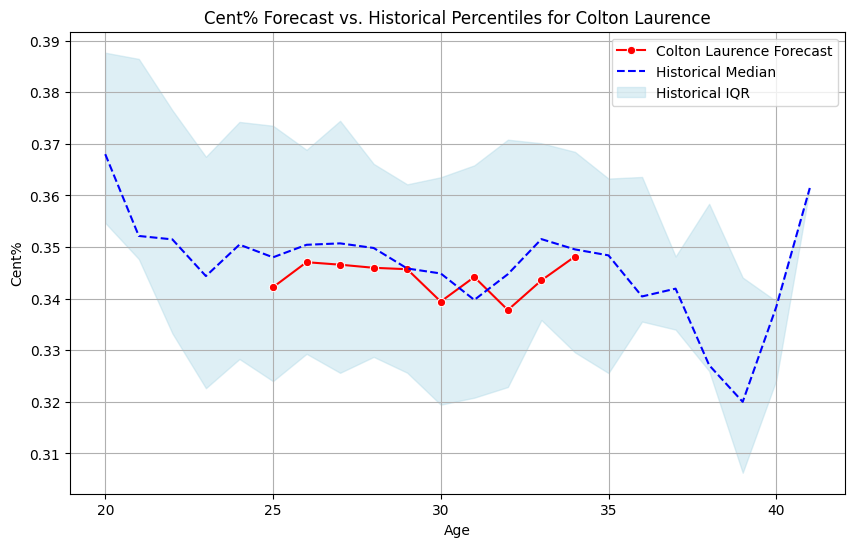

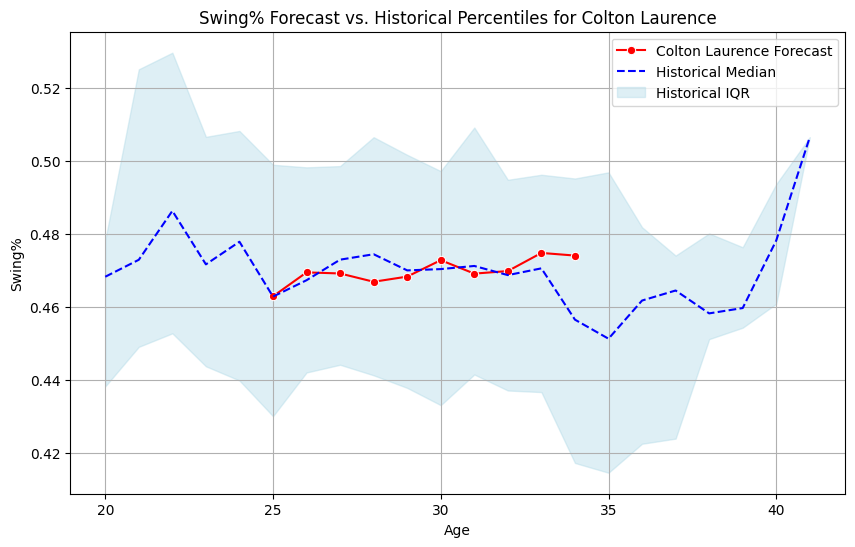

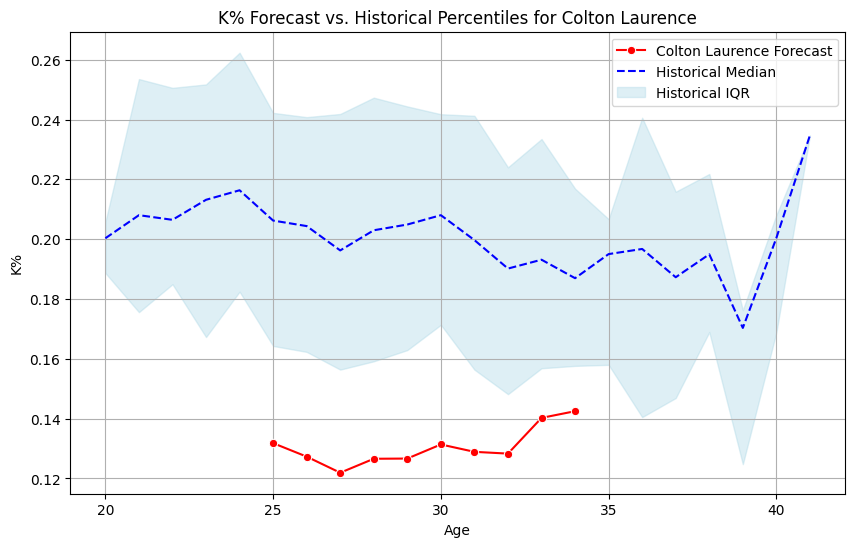

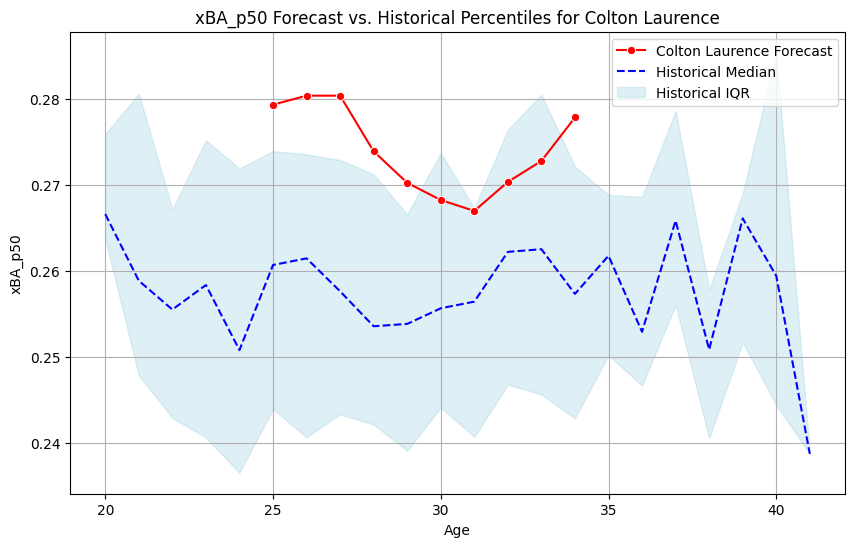

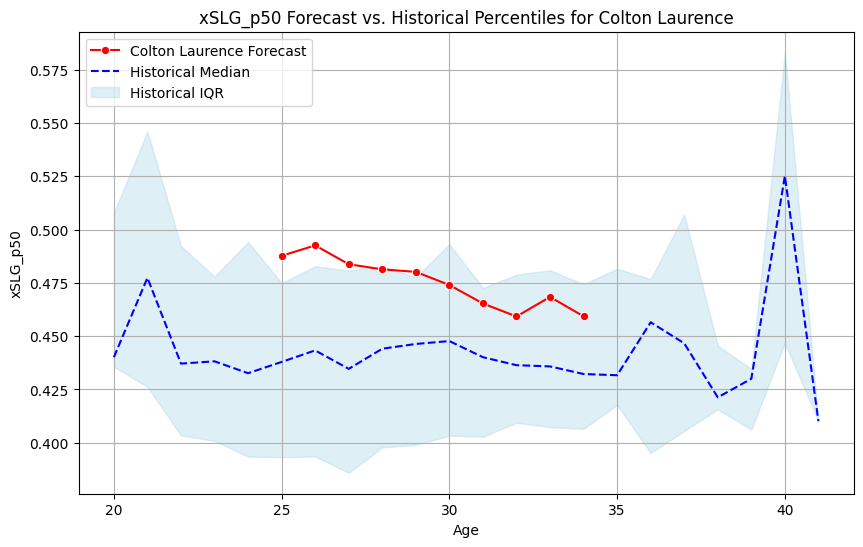

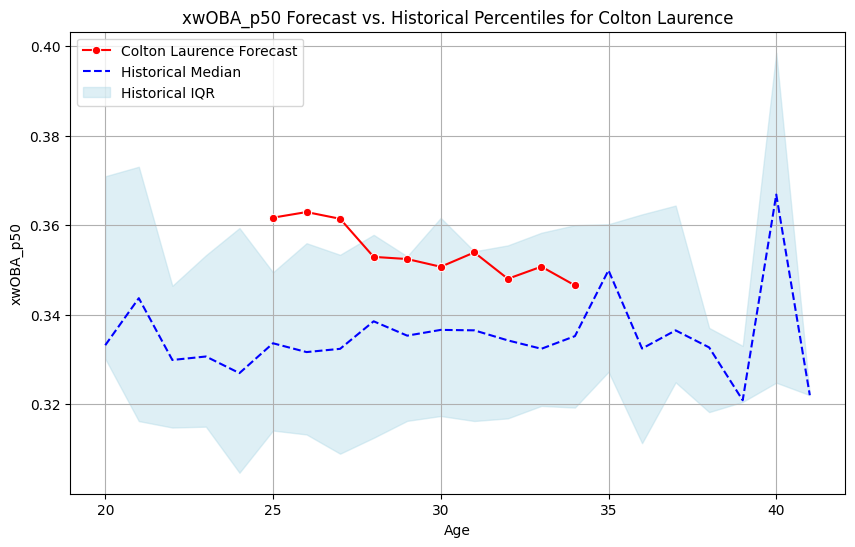

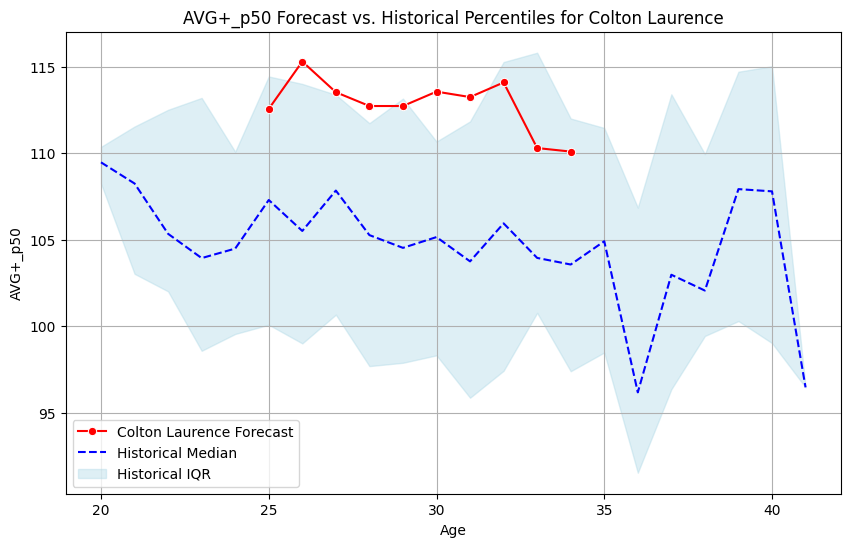

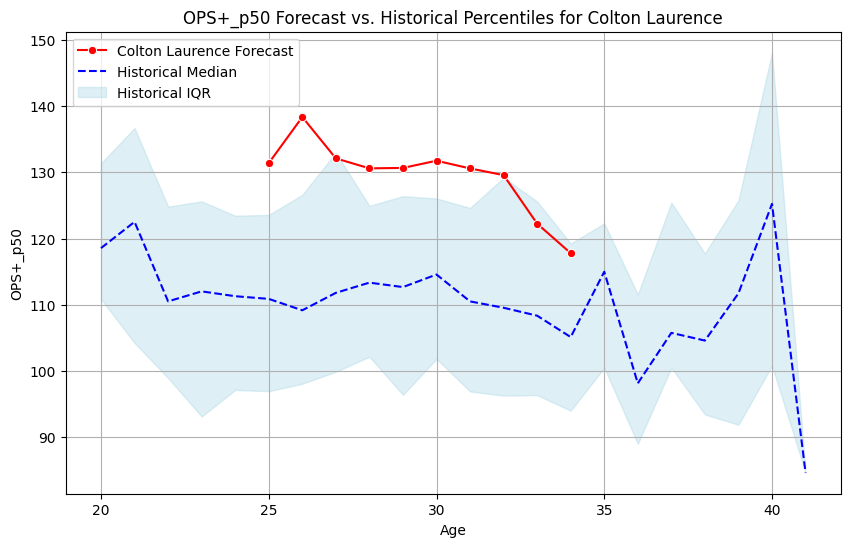

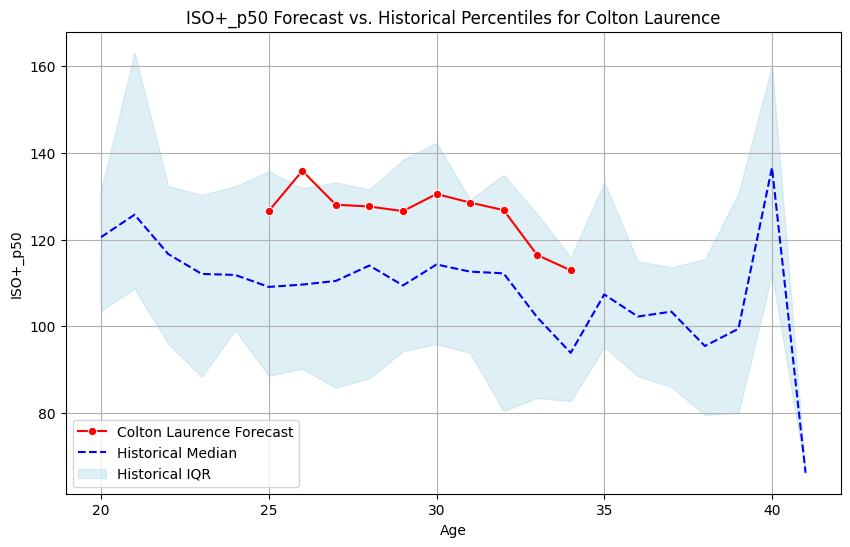

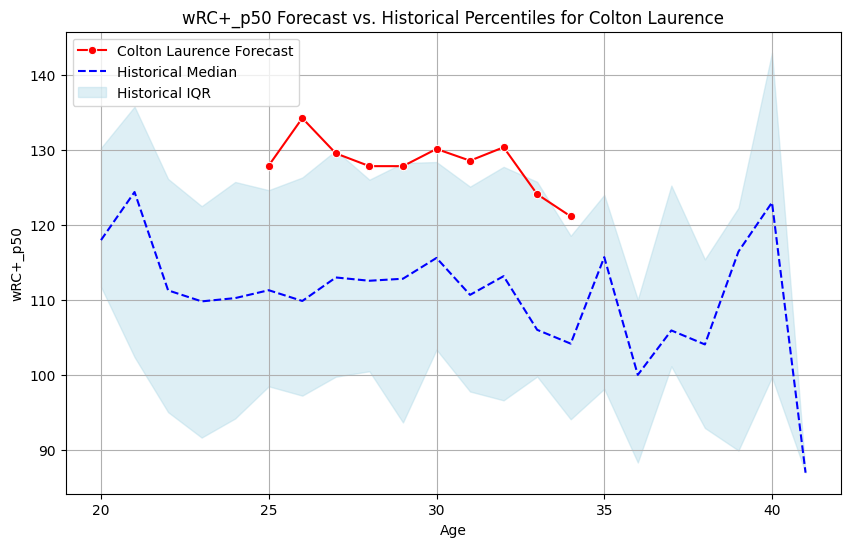

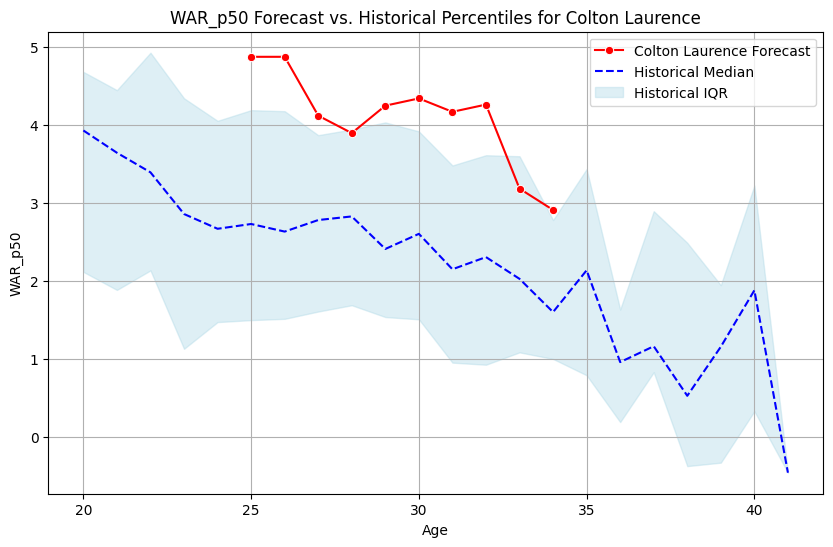

<Figure size 640x480 with 0 Axes>

In [22]:
forecast_df = forecast_10_years(player_name, player_age, seasons_data, stats)
print(f"\n10-Year Forecast for {player_name}:\n")
print(forecast_df.drop(columns=['Player Name'], errors='ignore'))
plot_forecast(forecast_df)
plot_comparative_forecast(forecast_df, stats)